### Overfitting
#### Solution?
# >> The OG HyperParameterTuning :)
It is of 3 types in general
1) GridSearch CV
2) Random Search CV
3) Bayesian Search [We will follow this]
###### We will do this via Optuna

[Link to Optuna Paper](https://arxiv.org/pdf/1907.10902)


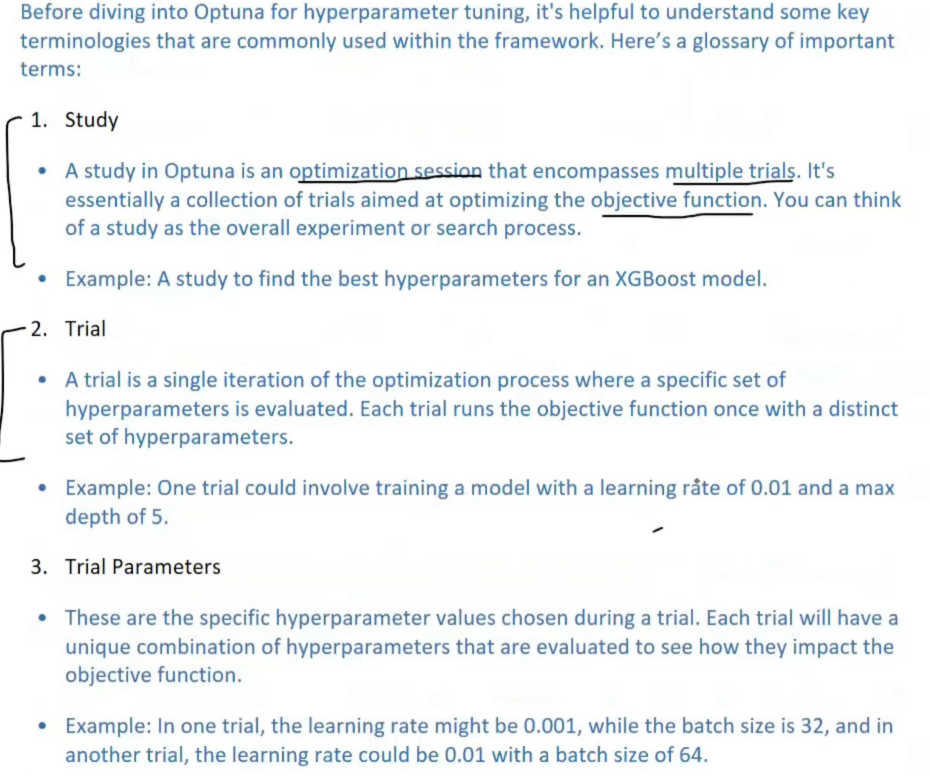
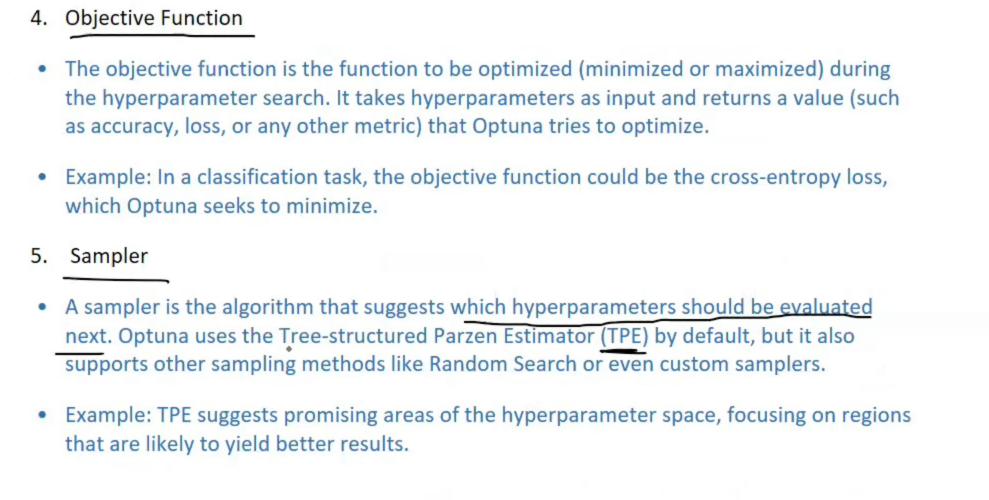
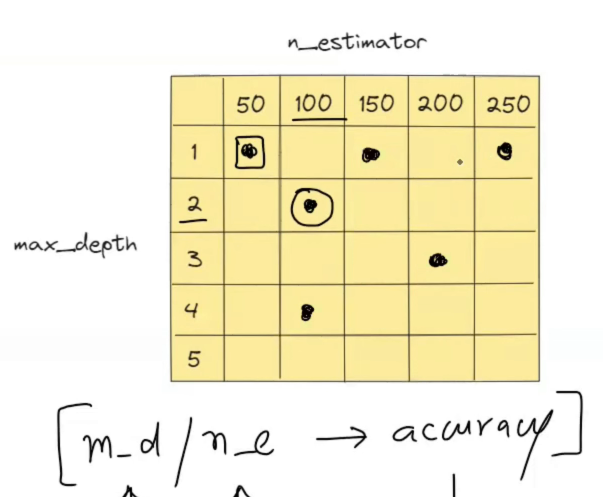


# Parameters We will Tune via Optuna

1) No of Hidden Layers
2) Neurons per layer
3) number of Epochs
4) Optimizer
5) Learning Rate
6) Batch Size
7) DropOut Rate
8) Weight Decay(lambda)

# Steps for Optuna

1) Make a Objective Function
    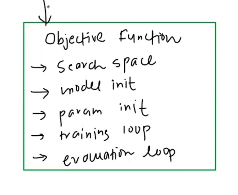
    1) [Input] This Objective Fn gets trial object as input
    2) We then define out search space(range of parameters)
    3) Initialize Model
    4) Initialize parameters (learning rate, neurons,etc)
    5) Run training Loop inside this
    6) Run Evaluation loop inside this
    7) [Output] Accuracy for that particular input trial
2) Create a Study Object where you define number of trials
3) Create trials with study object
4) Sent the trial to objective Function

# Load Data , Preprocess and get it ready for processing

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [3]:
torch.manual_seed(42)

In [4]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the specific CSV file
file_path = "fashion-mnist_train.csv"

# Load the dataset directly into a Pandas DataFrame
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "zalando-research/fashionmnist",
  file_path
)

print("First 5 records:", df.head())


/home/kartik-agarwal/Documents/DialogGPT/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


First 5 records:    label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      2       0       0       0       0       0       0       0       0   
1      9       0       0       0       0       0       0       0       0   
2      6       0       0       0       0       0       0       0       5   
3      0       0       0       0       1       2       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0        30        43         0   
3       0  ...         3         0         0         0         0         1   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0         0  

In [5]:
torch.device('cuda')

device(type='cuda')

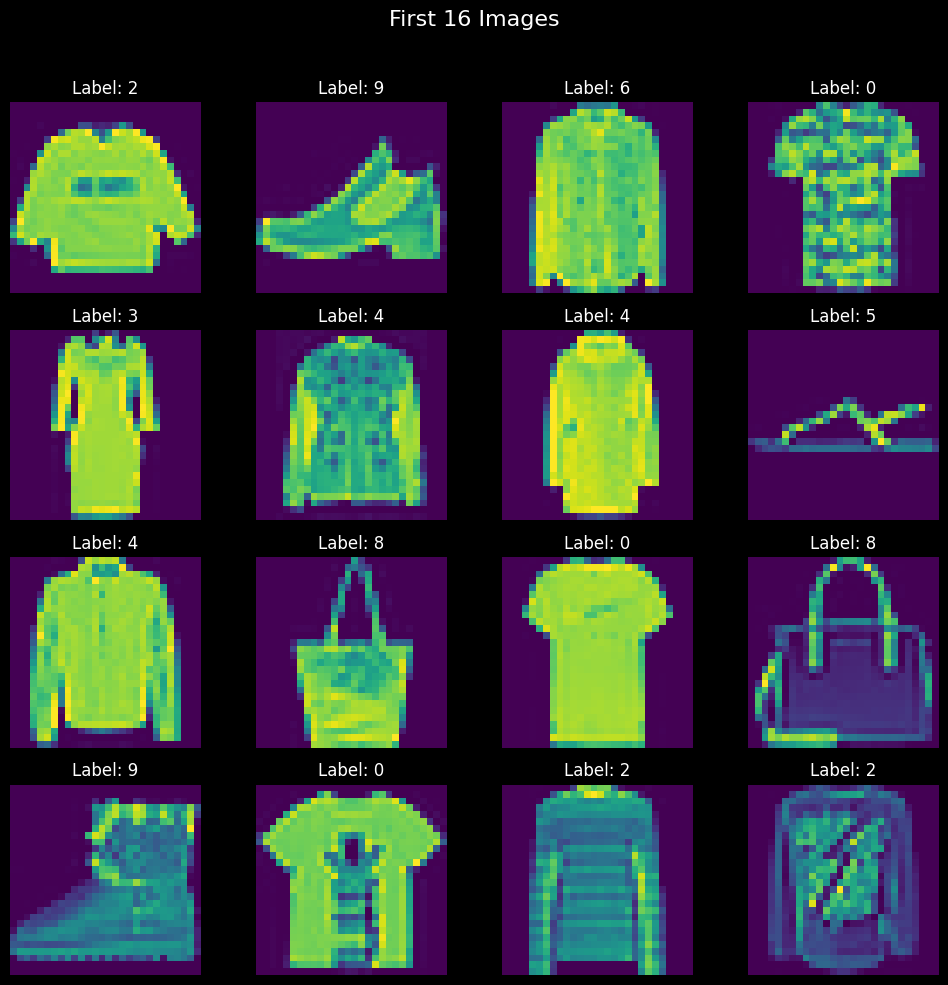

In [6]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()


In [7]:
# train test split

X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# scaling the feautures
X_train = X_train/255.0
X_test = X_test/255.0

In [1]:
# create CustomDataset Class
class CustomDataset(Dataset):

  def __init__(self, features, labels):

    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):

    return len(self.features)

  def __getitem__(self, index):

    return self.features[index], self.labels[index]



NameError: name 'Dataset' is not defined

In [11]:
# create train_dataset object
train_dataset = CustomDataset(X_train, y_train)

In [12]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.2275,
         0.5333, 0.0000, 0.0

In [13]:
# create test_dataset object
test_dataset = CustomDataset(X_test, y_test)

In [15]:
class MyNN(nn.Module):

  def __init__(self, input_dim, output_dim, num_hidden_layers, neurons_per_layer, dropout_rate):

    super().__init__()

    layers = []

    for i in range(num_hidden_layers):

      layers.append(nn.Linear(input_dim, neurons_per_layer))
      layers.append(nn.BatchNorm1d(neurons_per_layer))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(dropout_rate))
      input_dim = neurons_per_layer

    layers.append(nn.Linear(neurons_per_layer, output_dim))

    self.model = nn.Sequential(*layers)

  def forward(self, x):

    return self.model(x)

# Define Objective Fn Here

In [16]:
device = torch.device('cuda')# objective function
def objective(trial):

  # next hyperparameter values from the search space
  num_hidden_layers = trial.suggest_int("num_hidden_layers", 1, 5)
  neurons_per_layer = trial.suggest_int("neurons_per_layer", 8, 128, step=8)
  epochs = trial.suggest_int("epochs", 10, 50, step=10)
  learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
  dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5, step=0.1)
  batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])
  optimizer_name = trial.suggest_categorical("optimizer", ['Adam', 'SGD', 'RMSprop'])
  weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)

  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
  test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

  # model init
  input_dim = 784
  output_dim = 10

  model = MyNN(input_dim, output_dim, num_hidden_layers, neurons_per_layer, dropout_rate)
  model.to(device)

  # optimizer selection
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.SGD(model.parameters(), lr=0.1, weight_decay=1e-4)

  if optimizer_name == 'Adam':
    optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
  elif optimizer_name == 'SGD':
    optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
  else:
    optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

  # training loop

  for epoch in range(epochs):

    for batch_features, batch_labels in train_loader:

      # move data to gpu
      batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

      # forward pass
      outputs = model(batch_features)

      # calculate loss
      loss = criterion(outputs, batch_labels)

      # back pass
      optimizer.zero_grad()
      loss.backward()

      # update grads
      optimizer.step()


  # evaluation
  model.eval()
  # evaluation on test data
  total = 0
  correct = 0

  with torch.no_grad():

    for batch_features, batch_labels in test_loader:

      # move data to gpu
      batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

      outputs = model(batch_features)

      _, predicted = torch.max(outputs, 1)

      total = total + batch_labels.shape[0]

      correct = correct + (predicted == batch_labels).sum().item()

    accuracy = correct/total

  return accuracy

In [17]:
import optuna

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

# Paused it because it was taking too much time

[I 2026-03-01 00:23:47,730] A new study created in memory with name: no-name-b67f5468-90c8-4215-8038-f002c5e76e02
[I 2026-03-01 00:24:31,625] Trial 0 finished with value: 0.8808333333333334 and parameters: {'num_hidden_layers': 2, 'neurons_per_layer': 120, 'epochs': 50, 'learning_rate': 0.00021825364524713083, 'dropout_rate': 0.1, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 0.00012595609900410972}. Best is trial 0 with value: 0.8808333333333334.
[I 2026-03-01 00:26:17,885] Trial 1 finished with value: 0.8715 and parameters: {'num_hidden_layers': 5, 'neurons_per_layer': 48, 'epochs': 40, 'learning_rate': 4.10096105090202e-05, 'dropout_rate': 0.30000000000000004, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 0.0004804265890679024}. Best is trial 0 with value: 0.8808333333333334.
[I 2026-03-01 00:26:42,806] Trial 2 finished with value: 0.8663333333333333 and parameters: {'num_hidden_layers': 1, 'neurons_per_layer': 120, 'epochs': 10, 'learning_rate': 3.8324839105796

KeyboardInterrupt: 

In [ ]:
study.best_value